# WQI Regression — Paper-Ready Regression Plots

This is a **separate plotting notebook** for the Groundwater (GW) and Surface Water (SW) regression analyses.

It uses the two uploaded datasets:

- `gw_sanity.csv`
- `surface_wqi_pred.csv`

The notebook follows the regression structure in the two uploaded regression notebooks and creates compact figures suitable for a research paper.

## Figures produced

### Main-paper candidates
1. **Actual vs Predicted WQI — 5-panel figure**
2. **Model comparison — R² + RMSE in one figure**

### Diagnostic / supplementary candidates
3. **Residual diagnostics — 5-panel figure**
4. **Actual vs Predicted line plot for the best model**
5. **Feature vs WQI scatter plot**

The 5 models are Random Forest, Gradient Boosting, XGBoost, SVR/SVM, and Decision Tree.


## Important methodological note

The two uploaded notebooks are not identical.

### Groundwater notebook
The GW notebook:
- computes WQI from BIS limits;
- removes `iron_(ppm)` because it is almost perfectly correlated with WQI;
- augments the **full dataset before train/test splitting**;
- then imputes, scales, tunes and evaluates the models.

### Surface-water notebook
The SW notebook:
- removes target-leaking/useless columns;
- checks iron leakage;
- performs the **train/test split first**;
- augments the **training set only**;
- then imputes, scales, tunes and evaluates the models.

In [9]:
# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

sns.set_theme(style="whitegrid")


## 2. Simple meaning of the regression plots

**Actual vs Predicted scatter:**  
Each point is one test observation. The closer the point is to the diagonal `Actual = Predicted` line, the better the prediction.

**Line plot:**  
Actual and predicted WQI values are shown together for the test samples. Here the samples are sorted by actual WQI; this is a prediction-profile plot, **not a time-series plot**.

**Residual plot:**  
Residual = Actual − Predicted. Good residuals should be distributed around zero without an obvious systematic pattern.

**Model-comparison bar graph:**  
R² should be higher; RMSE should be lower.

For the final paper, the most informative compact combination is the **5-panel Actual-vs-Predicted figure + one two-panel R²/RMSE comparison figure**.


In [10]:
# 3. METRIC FUNCTIONS

def nse(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return 1 - (
        np.sum((y_true - y_pred) ** 2) /
        np.sum((y_true - np.mean(y_true)) ** 2)
    )

def metrics(y_true, y_pred):
    return {
        "R²": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "NSE": nse(y_true, y_pred)
    }


# PART A — GROUNDWATER

The following cells reproduce the important modelling steps from the uploaded GW notebook.


In [11]:
# 4. LOAD GROUNDWATER DATA AND COMPUTE BIS-BASED WQI

gw = pd.read_csv("gw_sanity.csv")

param_map = {
    "ph": "ph",
    "turbidity": "turbidity",
    "chloride": "chloride_(ppm)",
    "sulphate": "sulphates(ppm)",
    "nitrate": "nitrate(ppm)",
    "iron": "iron_(ppm)",
    "fluoride": "fluorides(ppm)",
    "conductivity": "conductivity"
}

bis_limits = {
    "ph": (6.5, 8.5),
    "turbidity": 5,
    "chloride": 250,
    "sulphate": 200,
    "nitrate": 45,
    "fluoride": 1.5,
    "iron": 0.3,
    "conductivity": 2000
}

weights = {
    k: 1 / v if not isinstance(v, tuple) else 1 / v[1]
    for k, v in bis_limits.items()
}

def compute_bis_wqi(data):
    values = []

    for _, row in data.iterrows():
        num = 0
        den = 0

        for p, limit in bis_limits.items():
            col = param_map[p]

            if col not in data.columns or pd.isna(row[col]):
                continue

            wi = weights[p]

            if p == "ph":
                qi = abs(row[col] - 7.0) / (8.5 - 7.0) * 100
            else:
                qi = (row[col] / limit) * 100

            num += wi * qi
            den += wi

        values.append(num / den if den != 0 else np.nan)

    result = data.copy()
    result["wqi"] = values
    return result

gw["wqi"] = compute_bis_wqi(gw)["wqi"]

print("GW shape:", gw.shape)
print("Missing WQI:", gw["wqi"].isna().sum())


GW shape: (42, 21)
Missing WQI: 0


### What this block represents

This is **target construction**. The notebook calculates the Water Quality Index from the groundwater physicochemical parameters using the BIS-based limits defined in the original notebook.

`wqi` becomes the regression target `y`.


In [12]:
# 5. REMOVE EMPTY / LEAKAGE FEATURES AND CREATE X AND y

always_nan = [c for c in gw.columns if gw[c].isna().all()]
gw.drop(columns=always_nan, inplace=True)

# Iron is part of the WQI calculation and is almost perfectly correlated with WQI.
# The original notebook removes it to avoid trivial target leakage.
if "iron_(ppm)" in gw.columns:
    gw.drop(columns=["iron_(ppm)"], inplace=True)

X_gw = gw.select_dtypes(include="number").drop(columns=["wqi"])
y_gw = gw["wqi"].dropna()
X_gw = X_gw.loc[y_gw.index]

print("GW features:")
print(list(X_gw.columns))
print("GW X shape:", X_gw.shape)


GW features:
['year', 'ph', 'turbidity', 'conductivity', 'chloride_(ppm)', 'sulphates(ppm)', 'cod(ppm)', 'bod(ppm)', 'do(ppm)', 'ammonia(ppm)', 'nitrate(ppm)', 'fluorides(ppm)', 'phosphates(ppm)', 'total_bacterial_count_(cfu/ml)', 'total_fungal_count_(cfu/ml)']
GW X shape: (42, 15)


### What this block represents

`X` contains the predictor variables and `y` contains WQI.

The leakage-removal step matters because a model should not be given a variable that effectively reveals the target itself.


In [13]:
# 6. GROUNDWATER DATA AUGMENTATION
# This mirrors the uploaded GW notebook: augmentation is performed before the split.

def augment_data(X, y, n_copies=3, noise_fraction=0.01, random_state=42):
    rng = np.random.RandomState(random_state)

    # Convert to float so Gaussian noise can be added safely.
    X = X.astype(float)
    feature_stds = X.std(skipna=True)

    X_list = [X.copy()]
    y_list = [y.copy()]

    for _ in range(n_copies):
        X_noisy = X.copy()

        for col in X.columns:
            std = feature_stds[col]

            if std == 0 or np.isnan(std):
                continue

            noise = rng.normal(
                0,
                noise_fraction * std,
                size=len(X)
            )

            mask = X_noisy[col].notna()
            X_noisy.loc[mask, col] += noise[mask]

        # Same small target noise used in the original notebook.
        y_noisy = y + rng.normal(
            0,
            0.005 * y.std(),
            size=len(y)
        )

        X_list.append(X_noisy)
        y_list.append(y_noisy)

    return (
        pd.concat(X_list, ignore_index=True),
        pd.concat(y_list, ignore_index=True)
    )

X_gw_aug, y_gw_aug = augment_data(X_gw, y_gw)

print("Original:", X_gw.shape)
print("After augmentation:", X_gw_aug.shape)


Original: (42, 15)
After augmentation: (168, 15)


In [14]:
# 7. GROUNDWATER TRAIN/TEST SPLIT, IMPUTATION AND SCALING

X_train_gw, X_test_gw, y_train_gw, y_test_gw = train_test_split(
    X_gw_aug,
    y_gw_aug,
    test_size=0.2,
    random_state=42
)

imputer_gw = KNNImputer(n_neighbors=5)

X_train_gw_imp = imputer_gw.fit_transform(X_train_gw)
X_test_gw_imp = imputer_gw.transform(X_test_gw)

scaler_gw = StandardScaler()

X_train_gw_sc = scaler_gw.fit_transform(X_train_gw_imp)
X_test_gw_sc = scaler_gw.transform(X_test_gw_imp)

print("GW train:", X_train_gw_sc.shape)
print("GW test:", X_test_gw_sc.shape)


GW train: (134, 15)
GW test: (34, 15)


### What these steps mean

**Train/test split:** separates data used for model fitting from held-out data used for final evaluation.

**KNN imputation:** fills missing predictor values using nearby observations.

**StandardScaler:** puts predictors onto a comparable numerical scale. This is particularly relevant for SVR/SVM.


In [15]:
# 8. GROUNDWATER MODELS AND HYPERPARAMETER TUNING

param_grids = {
    "Random Forest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [None, 5, 10],
            "min_samples_split": [2, 5]
        }
    },
    "Gradient Boosting": {
        "model": GradientBoostingRegressor(random_state=42),
        "params": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.05, 0.1, 0.2],
            "max_depth": [3, 5]
        }
    },
    "XGBoost": {
        "model": XGBRegressor(random_state=42, verbosity=0),
        "params": {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.05, 0.1],
            "max_depth": [3, 5, 7]
        }
    },
    "SVR": {
        "model": SVR(),
        "params": {
            "C": [1, 10, 100],
            "gamma": ["scale", "auto", 0.1],
            "kernel": ["rbf", "linear"]
        }
    },
    "Decision Tree": {
        "model": DecisionTreeRegressor(random_state=42),
        "params": {
            "max_depth": [None, 3, 5, 10],
            "min_samples_split": [2, 5, 10]
        }
    }
}

best_models_gw = {}
rows = []

for name, cfg in param_grids.items():

    grid = GridSearchCV(
        cfg["model"],
        cfg["params"],
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    grid.fit(X_train_gw_sc, y_train_gw)

    model = grid.best_estimator_
    pred = model.predict(X_test_gw_sc)

    best_models_gw[name] = model

    m = metrics(y_test_gw, pred)

    rows.append([
        name,
        m["R²"],
        m["RMSE"],
        m["MAE"],
        m["NSE"]
    ])

gw_results = pd.DataFrame(
    rows,
    columns=["Model", "R²", "RMSE", "MAE", "NSE"]
).sort_values("R²", ascending=False).reset_index(drop=True)

gw_results


,Model,R²,RMSE,MAE,NSE
0,Decision Tree,0.999934,2.448674,1.927944,0.999934
1,Gradient Boosting,0.999811,4.146088,3.364830,0.999811
2,Random Forest,0.999011,9.485500,7.008390,0.999011
3,XGBoost,0.989440,30.989589,24.499622,0.989440
4,SVR,0.856320,114.307314,25.083268,0.856320


### What this block represents

`GridSearchCV` tries the combinations in each parameter grid and selects the combination with the best cross-validated R² on the training data.

The selected model is then used to predict the **held-out test set**.

# PART B — SURFACE WATER

This follows the uploaded SW notebook, including its important distinction that augmentation is performed **after the train/test split and only on the training data**.

In [16]:
# 9. LOAD AND CLEAN SURFACE-WATER DATA

sw = pd.read_csv("surface_wqi_pred.csv")

near_empty = [
    c for c in sw.columns
    if sw[c].isna().all() or sw[c].isna().sum() >= len(sw) - 1
]

sw.drop(columns=near_empty, errors="ignore", inplace=True)

for col in ["WQI_Pred", "WQI_Class", "Hotspot"]:
    if col in sw.columns:
        sw.drop(columns=[col], inplace=True)

numeric_sw = sw.select_dtypes(include="number")

if "Iron (ppm)" in numeric_sw.columns and "WQI" in numeric_sw.columns:

    iron_corr = numeric_sw["Iron (ppm)"].corr(numeric_sw["WQI"])
    print("Iron-WQI correlation:", round(iron_corr, 4))

    if abs(iron_corr) > 0.95:
        sw.drop(columns=["Iron (ppm)"], inplace=True)

X_sw = sw.select_dtypes(include="number").drop(columns=["WQI"])
y_sw = sw["WQI"]

print("SW features:")
print(list(X_sw.columns))
print("SW X shape:", X_sw.shape)


Iron-WQI correlation: 0.2192
SW features:
['Year', 'pH', 'Turbidity', 'Conductivity', 'Chloride (ppm)', 'Sulphates(ppm)', 'Iron (ppm)', 'COD(ppm)', 'BOD(ppm)', 'DO(ppm)', 'Ammonia(ppm)', 'Nitrate(ppm)', 'Fluorides(ppm)', 'Total Bacterial Count (cfu/ml)', 'Total Fungal Count (cfu/ml)']
SW X shape: (42, 15)


### What this block represents

The SW notebook explicitly removes:

- `WQI_Pred`
- `WQI_Class`
- `Hotspot`

because they can leak information about the target.

It also removes near-empty variables and checks whether iron is almost perfectly correlated with WQI.


In [17]:
# 10. SURFACE-WATER TRAIN/TEST SPLIT

X_train_sw, X_test_sw, y_train_sw, y_test_sw = train_test_split(
    X_sw,
    y_sw,
    test_size=0.2,
    random_state=42
)

print("SW train:", X_train_sw.shape)
print("SW test:", X_test_sw.shape)


SW train: (33, 15)
SW test: (9, 15)


In [18]:
# 11. SURFACE-WATER AUGMENTATION — TRAINING SET ONLY

X_train_sw_aug, y_train_sw_aug = augment_data(
    X_train_sw,
    y_train_sw
)

print("Original SW training set:", X_train_sw.shape)
print("Augmented SW training set:", X_train_sw_aug.shape)


Original SW training set: (33, 15)
Augmented SW training set: (132, 15)


In [19]:
# 12. SURFACE-WATER IMPUTATION AND SCALING

imputer_sw = KNNImputer(n_neighbors=5)

X_train_sw_imp = imputer_sw.fit_transform(X_train_sw_aug)
X_test_sw_imp = imputer_sw.transform(X_test_sw)

scaler_sw = StandardScaler()

X_train_sw_sc = scaler_sw.fit_transform(X_train_sw_imp)
X_test_sw_sc = scaler_sw.transform(X_test_sw_imp)

print("SW train after preprocessing:", X_train_sw_sc.shape)
print("SW test after preprocessing:", X_test_sw_sc.shape)


SW train after preprocessing: (132, 15)
SW test after preprocessing: (9, 15)


In [20]:
# 13. SURFACE-WATER MODEL TRAINING AND TUNING

best_models_sw = {}
rows = []

# Same model/parameter structure as the uploaded SW notebook.
for name, cfg in param_grids.items():

    grid = GridSearchCV(
        cfg["model"],
        cfg["params"],
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    grid.fit(X_train_sw_sc, y_train_sw_aug)

    model = grid.best_estimator_
    pred = model.predict(X_test_sw_sc)

    best_models_sw[name] = model

    m = metrics(y_test_sw, pred)

    rows.append([
        name,
        m["R²"],
        m["RMSE"],
        m["MAE"],
        m["NSE"]
    ])

sw_results = pd.DataFrame(
    rows,
    columns=["Model", "R²", "RMSE", "MAE", "NSE"]
).sort_values("R²", ascending=False).reset_index(drop=True)

sw_results


,Model,R²,RMSE,MAE,NSE
0,SVR,0.925302,4.847964,3.899157,0.925302
1,Random Forest,0.871651,6.354798,4.340650,0.871651
2,XGBoost,0.861351,6.604850,4.000870,0.861351
3,Gradient Boosting,0.842243,7.045287,5.357930,0.842243
4,Decision Tree,0.731040,9.199174,6.912551,0.731040


# PART C - PAPER FIGURES

## Figure 1/2 - Actual vs Predicted WQI

This is the most important regression diagnostic for the paper.

### Reading the plot

- x-axis = actual observed WQI
- y-axis = predicted WQI
- diagonal dashed line = perfect prediction
- points close to the diagonal = better predictions
- R² and RMSE are written inside each panel

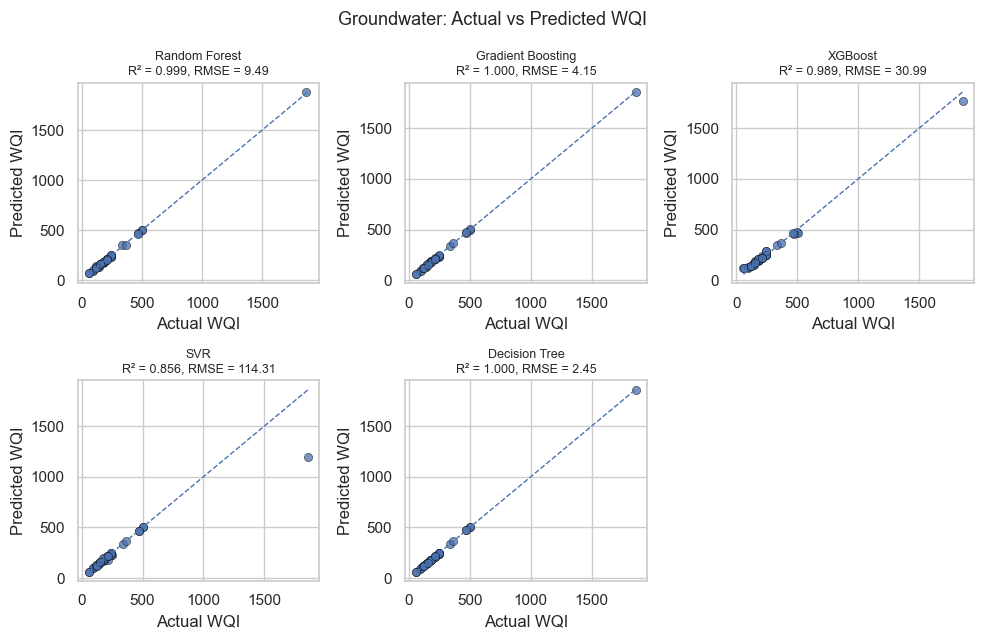

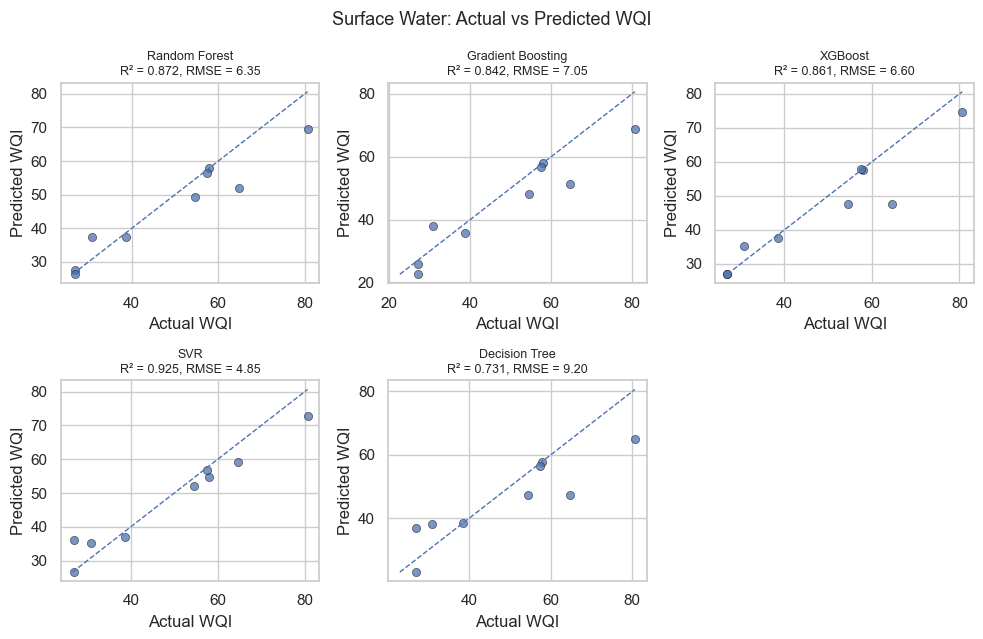

In [21]:
# 14. COMPACT ACTUAL-VS-PREDICTED SCATTER PLOT

def actual_vs_predicted_grid(
    models,
    X_test,
    y_test,
    water_name,
    save_name
):

    fig, axes = plt.subplots(2, 3, figsize=(10, 6.5))
    axes = axes.ravel()

    y_test = np.asarray(y_test)

    for i, (name, model) in enumerate(models.items()):

        pred = model.predict(X_test)

        # Main scatter plot
        axes[i].scatter(
            y_test,
            pred,
            s=35,
            alpha=0.75,
            edgecolors="black",
            linewidth=0.4
        )

        # Perfect-prediction line
        low = min(y_test.min(), pred.min())
        high = max(y_test.max(), pred.max())

        axes[i].plot(
            [low, high],
            [low, high],
            "--",
            linewidth=1
        )

        r2 = r2_score(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))

        axes[i].set_title(
            f"{name}\nR² = {r2:.3f}, RMSE = {rmse:.2f}",
            fontsize=9
        )

        axes[i].set_xlabel("Actual WQI")
        axes[i].set_ylabel("Predicted WQI")

    # Five models occupy five panels; sixth panel is unused.
    axes[-1].axis("off")

    fig.suptitle(
        f"{water_name}: Actual vs Predicted WQI",
        fontsize=13
    )

    plt.tight_layout()
    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()


actual_vs_predicted_grid(
    best_models_gw,
    X_test_gw_sc,
    y_test_gw,
    "Groundwater",
    "GW_actual_vs_predicted_5panel.png"
)

actual_vs_predicted_grid(
    best_models_sw,
    X_test_sw_sc,
    y_test_sw,
    "Surface Water",
    "SW_actual_vs_predicted_5panel.png"
)


## Figure 3/4 — Residual diagnostics

Residual = **Actual − Predicted**.

The horizontal zero line is the reference.

A good model should ideally have residuals scattered around zero rather than showing a clear curve, trend, or funnel.


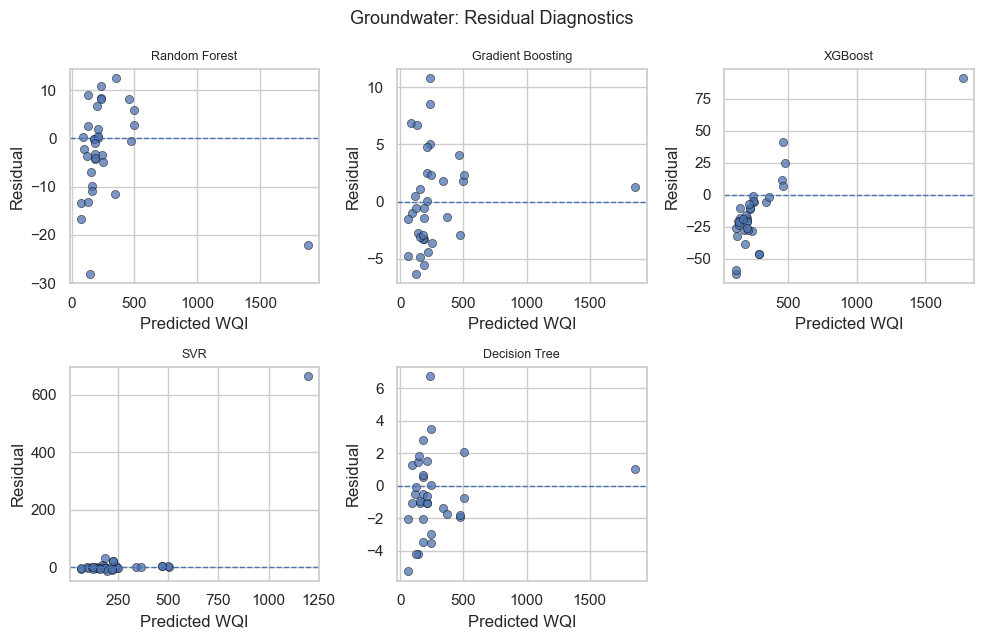

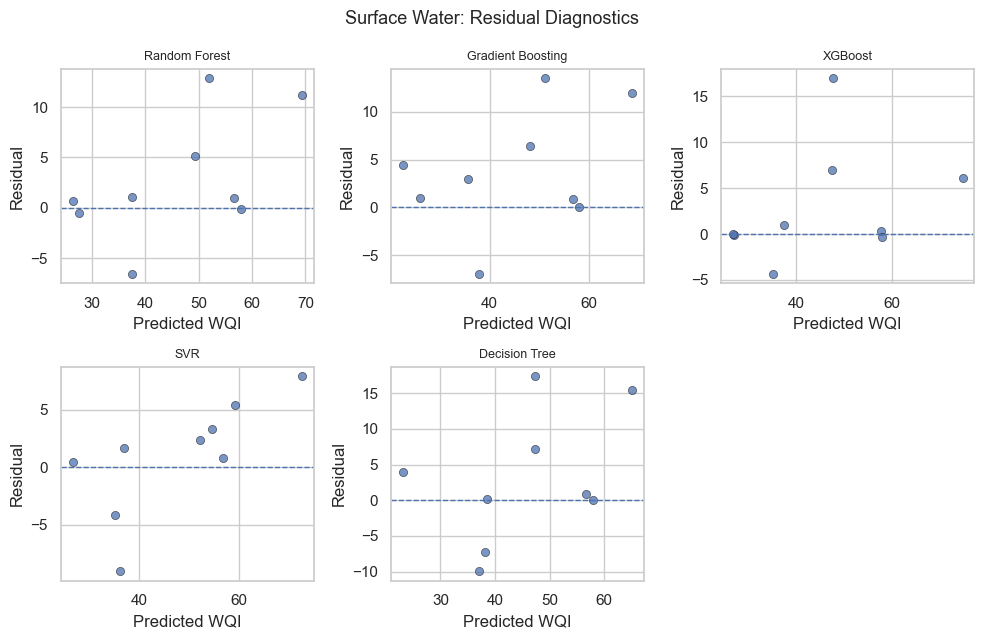

In [22]:
# 15. COMPACT RESIDUAL PLOTS FOR ALL FIVE MODELS

def residual_grid(
    models,
    X_test,
    y_test,
    water_name,
    save_name
):

    fig, axes = plt.subplots(2, 3, figsize=(10, 6.5))
    axes = axes.ravel()

    y_test = np.asarray(y_test)

    for i, (name, model) in enumerate(models.items()):

        pred = model.predict(X_test)

        residual = y_test - pred

        axes[i].scatter(
            pred,
            residual,
            s=35,
            alpha=0.75,
            edgecolors="black",
            linewidth=0.4
        )

        axes[i].axhline(
            0,
            linestyle="--",
            linewidth=1
        )

        axes[i].set_title(name, fontsize=9)
        axes[i].set_xlabel("Predicted WQI")
        axes[i].set_ylabel("Residual")

    axes[-1].axis("off")

    fig.suptitle(
        f"{water_name}: Residual Diagnostics",
        fontsize=13
    )

    plt.tight_layout()
    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()


residual_grid(
    best_models_gw,
    X_test_gw_sc,
    y_test_gw,
    "Groundwater",
    "GW_residuals_5panel.png"
)

residual_grid(
    best_models_sw,
    X_test_sw_sc,
    y_test_sw,
    "Surface Water",
    "SW_residuals_5panel.png"
)


## Figure 5/6 — Actual vs Predicted line plot
The test observations are sorted by actual WQI first. This prevents the line from simply following the arbitrary row order of the CSV.

**Do not call this a time-series plot** unless the observations are genuinely ordered in time.

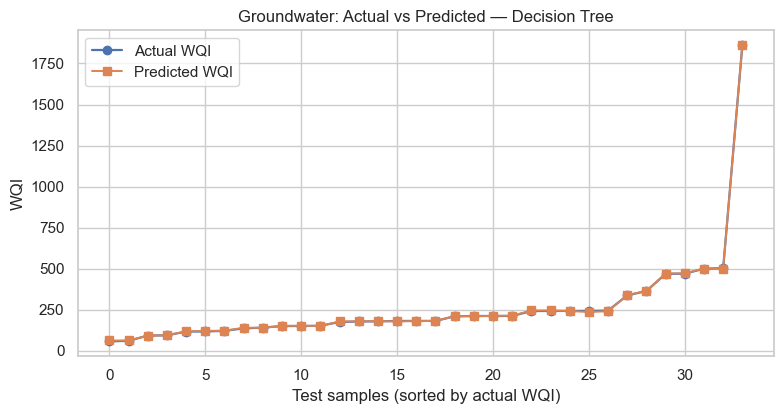

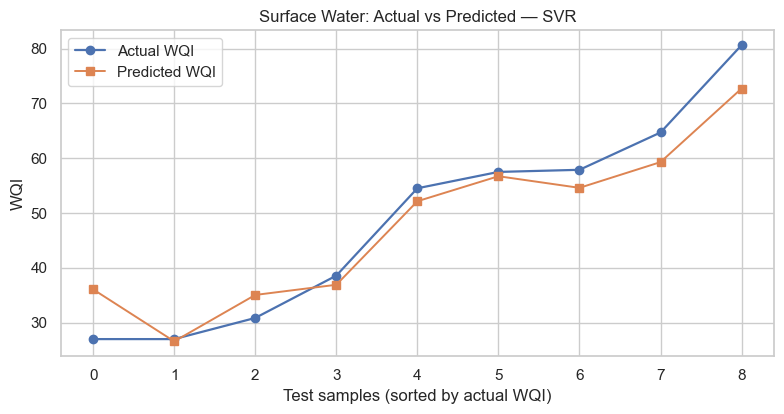

In [23]:
# 16. ACTUAL VS PREDICTED LINE PLOT FOR THE BEST MODEL

def best_model_line_plot(
    models,
    results,
    X_test,
    y_test,
    water_name,
    save_name
):

    best_name = results.iloc[0]["Model"]
    model = models[best_name]

    y = np.asarray(y_test)
    pred = model.predict(X_test)

    order = np.argsort(y)

    plt.figure(figsize=(8, 4.3))

    plt.plot(
        np.arange(len(y)),
        y[order],
        marker="o",
        linewidth=1.6,
        label="Actual WQI"
    )

    plt.plot(
        np.arange(len(y)),
        pred[order],
        marker="s",
        linewidth=1.4,
        label="Predicted WQI"
    )

    plt.xlabel("Test samples (sorted by actual WQI)")
    plt.ylabel("WQI")

    plt.title(
        f"{water_name}: Actual vs Predicted — {best_name}"
    )

    plt.legend()
    plt.tight_layout()

    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()


best_model_line_plot(
    best_models_gw,
    gw_results,
    X_test_gw_sc,
    y_test_gw,
    "Groundwater",
    "GW_best_model_line.png"
)

best_model_line_plot(
    best_models_sw,
    sw_results,
    X_test_sw_sc,
    y_test_sw,
    "Surface Water",
    "SW_best_model_line.png"
)


## Figure 7/8 — Combined R² and RMSE comparison
- GW R²
- GW RMSE
- SW R²
- SW RMSE

each water type gets one compact two-panel figure.

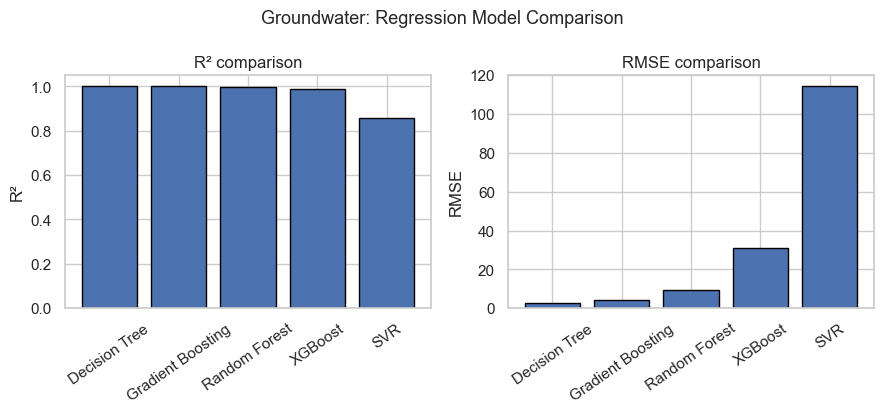

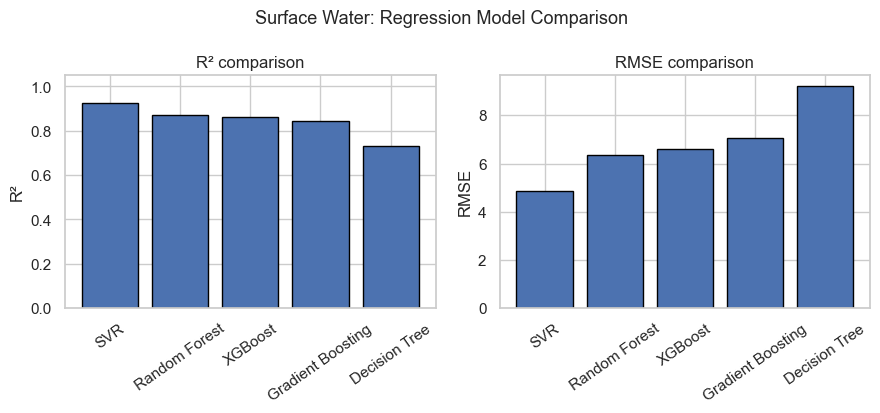

In [24]:
# 17. COMBINED R² + RMSE BAR GRAPH

def model_comparison(
    results,
    water_name,
    save_name
):

    fig, axes = plt.subplots(
        1, 2,
        figsize=(9, 4.2)
    )

    # R²
    axes[0].bar(
        results["Model"],
        results["R²"],
        edgecolor="black"
    )

    axes[0].set_title("R² comparison")
    axes[0].set_ylabel("R²")
    axes[0].set_ylim(0, 1.05)

    # RMSE
    axes[1].bar(
        results["Model"],
        results["RMSE"],
        edgecolor="black"
    )

    axes[1].set_title("RMSE comparison")
    axes[1].set_ylabel("RMSE")

    for ax in axes:
        ax.tick_params(
            axis="x",
            rotation=35
        )

    fig.suptitle(
        f"{water_name}: Regression Model Comparison",
        fontsize=13
    )

    plt.tight_layout()
    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()


model_comparison(
    gw_results,
    "Groundwater",
    "GW_model_comparison_R2_RMSE.png"
)

model_comparison(
    sw_results,
    "Surface Water",
    "SW_model_comparison_R2_RMSE.png"
)


## Optional scatter plot — parameter vs WQI

If your "scatter plot" means a relationship between an individual water-quality parameter and WQI, use this.

Do not automatically plot every parameter in the main paper. Select parameters that have a scientific reason to be discussed, or move the complete set to supplementary material.


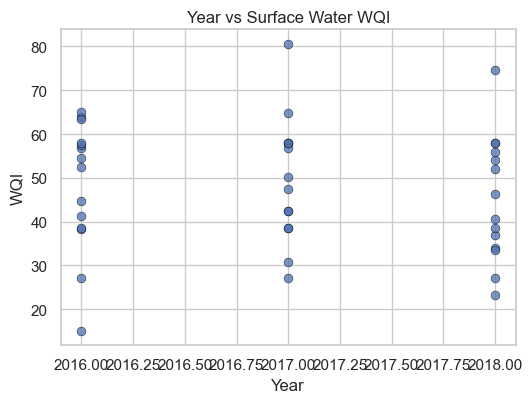

In [25]:
# 18. SIMPLE FEATURE-VS-WQI SCATTER PLOT

# Change this variable to the parameter you want to investigate.
feature = X_sw.columns[0]

plt.figure(figsize=(5.5, 4.2))

plt.scatter(
    sw[feature],
    sw["WQI"],
    s=40,
    alpha=0.75,
    edgecolors="black",
    linewidth=0.4
)

plt.xlabel(feature)
plt.ylabel("WQI")
plt.title(f"{feature} vs Surface Water WQI")

plt.tight_layout()
plt.savefig(
    "SW_feature_vs_WQI_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 19. FINAL RESULTS TABLES

These tables let you verify the numbers used in the figures.


In [26]:
print("GROUNDWATER RESULTS")
display(gw_results)

print("\nSURFACE WATER RESULTS")
display(sw_results)


GROUNDWATER RESULTS


,Model,R²,RMSE,MAE,NSE
0,Decision Tree,0.999934,2.448674,1.927944,0.999934
1,Gradient Boosting,0.999811,4.146088,3.364830,0.999811
2,Random Forest,0.999011,9.485500,7.008390,0.999011
3,XGBoost,0.989440,30.989589,24.499622,0.989440
4,SVR,0.856320,114.307314,25.083268,0.856320



SURFACE WATER RESULTS


,Model,R²,RMSE,MAE,NSE
0,SVR,0.925302,4.847964,3.899157,0.925302
1,Random Forest,0.871651,6.354798,4.340650,0.871651
2,XGBoost,0.861351,6.604850,4.000870,0.861351
3,Gradient Boosting,0.842243,7.045287,5.357930,0.842243
4,Decision Tree,0.731040,9.199174,6.912551,0.731040
